In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import (Dense, Flatten, Reshape, Convolution2D, MaxPooling2D, AveragePooling2D, Concatenate, InputLayer,
                                        ## data augmentation:
                                        Rescaling, RandomRotation, RandomFlip, RandomZoom, RandomTranslation, RandomBrightness,
                                        ## regularisation:
                                        Dropout
                                        ) 

from keras import Sequential, Input, Model

import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import pathlib

In [36]:
## plot and evaluate model

def plot_confusion_matrix_counts_percent(y_true, y_pred, class_names=None, figsize=(6,6)):
    """
    Plots a confusion matrix showing counts and percentages.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    if class_names is None:
        class_names = [str(i) for i in range(len(cm))]

    labels = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            labels[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix (counts + %)')
    plt.show()



def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()

In [67]:
data_dir = pathlib.Path("CIFAKE")

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / "train",
    image_size=(32, 32),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / "test",
    image_size=(32, 32),
    batch_size=32,
    shuffle=False
)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [7]:
def dataset_to_numpy(ds):
    images = []
    labels = []
    for batch_images, batch_labels in ds:
        images.append(batch_images.numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(images), np.concatenate(labels)

In [21]:
# Convert datasets to NumPy arrays
X_train, y_train = dataset_to_numpy(train_ds)
X_test, y_test = dataset_to_numpy(test_ds)

In [ ]:
print('X_train shape:', X_train.shape)   # 100_000 lignes/number of images, 32x32 pixels, 3 channels (R, G, B)
print('y_train shape:', y_train.shape)   # 100_000 labels
print('X_test shape:', X_test.shape)    # 20_000 lignes/number of images, 32x32 pixels, 3 channels (R, G, B)
print('y_test shape:', y_test.shape)    # 20_000 labels

X_train shape: (100000, 32, 32, 3)
y_train shape: (100000,)
X_test shape: (20000, 32, 32, 3)
y_test shape: (20000,)


In [12]:
X_train.dtype

dtype('float32')

In [13]:
np.sum(np.isnan(X_train),axis=None)

np.int64(0)

### Visualize a few samples per class

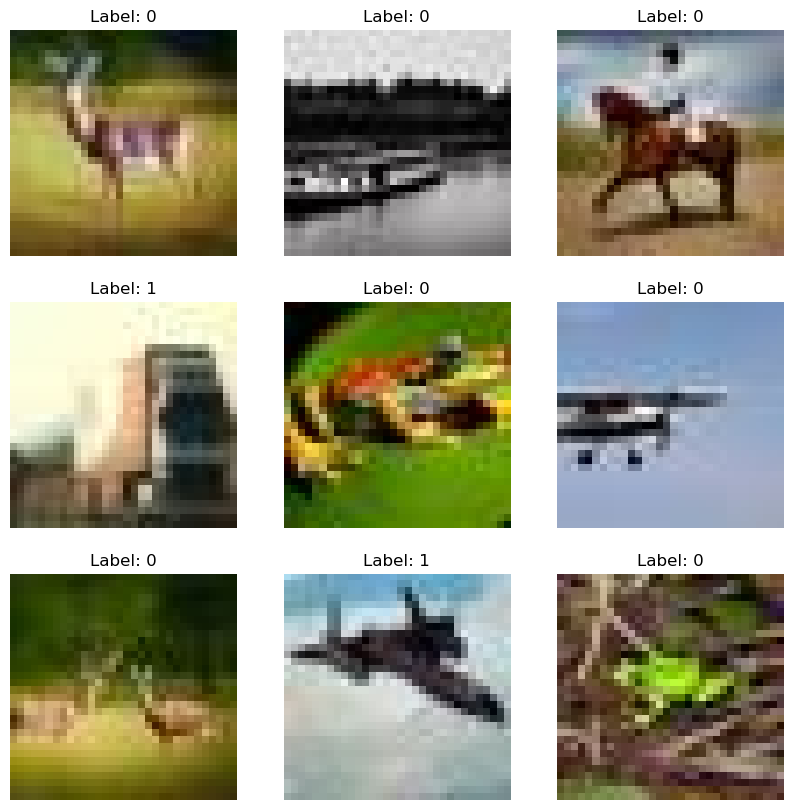

In [ ]:
def show_batch(ds):
    images, labels = next(iter(ds))
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Label: {labels[i].numpy()}')
        plt.axis('off')

show_batch(train_ds)

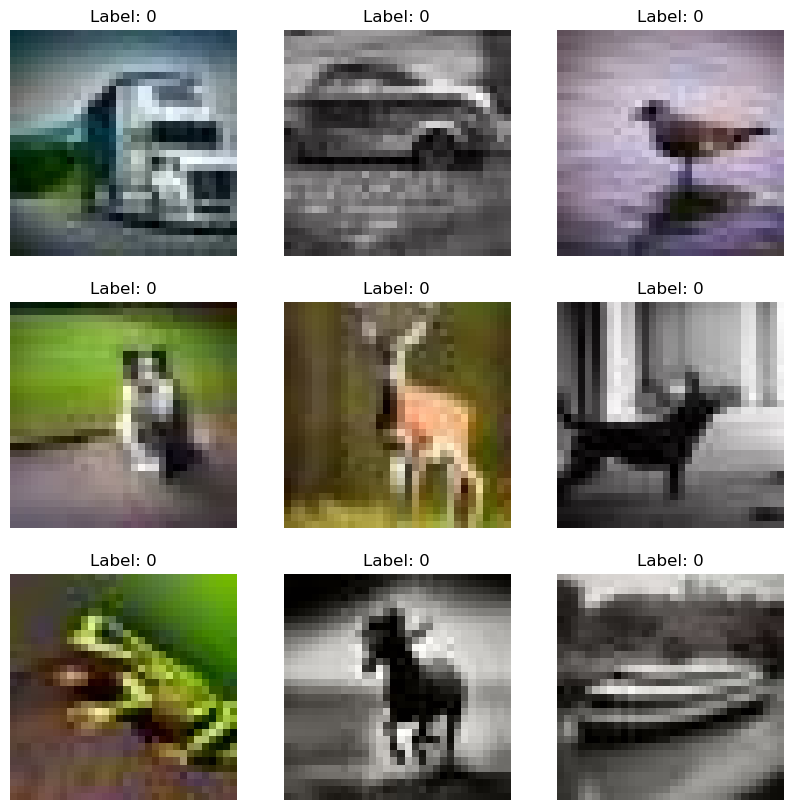

In [15]:
show_batch(test_ds)

### Check image batch shape

In [16]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 32, 32, 3)


32 → number of images in the batch

32 → image height

32 → image width

3 → RGB channels

### Check class distribution

In [17]:
_, y_train = dataset_to_numpy(train_ds)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(50000), np.int32(1): np.int64(50000)}


index 0 → 'FAKE'

index 1 → 'REAL'

Check class distribution: perfectly balanced.

### Check pixel value ranges

In [ ]:
print('Min:', X_train.min(), 'Max:', X_train.max())

Min: 0.0 Max: 255.0


In [23]:
X_test = X_test/np.max(X_test,axis=None)

### Data augmentation

In [ ]:
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.05),          # ~5% rotation (≈ ±9°)
    RandomZoom(0.1),               # slight zoom
    RandomTranslation(0.1, 0.1),   # small shifts
    RandomBrightness(factor=0.1),  # mild brightness change
], name='data_augmentation')

### Build model using Keras Functional API

In [ ]:
IMG_SHAPE=(32, 32, 3)
ACTIVATION='relu'

inputs = Input(IMG_SHAPE)

x = data_augmentation(inputs)   # apply data augmentation as a preprocessing layer at the start

x = Rescaling(1./255)(x)      # normalize after augmentation

x = Convolution2D(32, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)

x = Flatten()(x)

x = Dense(64, activation=ACTIVATION)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary() # see architecture

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [ ]:
model_history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 186s 59ms/step - accuracy: 0.7673 - loss: 0.4764 - val_accuracy: 0.7075 - val_loss: 0.5943
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.8310 - loss: 0.3743 - val_accuracy: 0.6948 - val_loss: 0.6896
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 74s 24ms/step - accuracy: 0.8520 - loss: 0.3372 - val_accuracy: 0.7868 - val_loss: 0.4724
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.8660 - loss: 0.3105 - val_accuracy: 0.7997 - val_loss: 0.4391
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.8767 - loss: 0.2900 - val_accuracy: 0.7436 - val_loss: 0.5877
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.8812 - loss: 0.2798 - val_accuracy: 0.8270 - val_loss: 0.4060
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.8862 - loss: 0.2698 - val_accuracy: 0.8022 - val_loss: 0.4563
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.8906 

### Evaluate model

In [27]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8396 - loss: 0.3938
Test Accuracy: 0.84


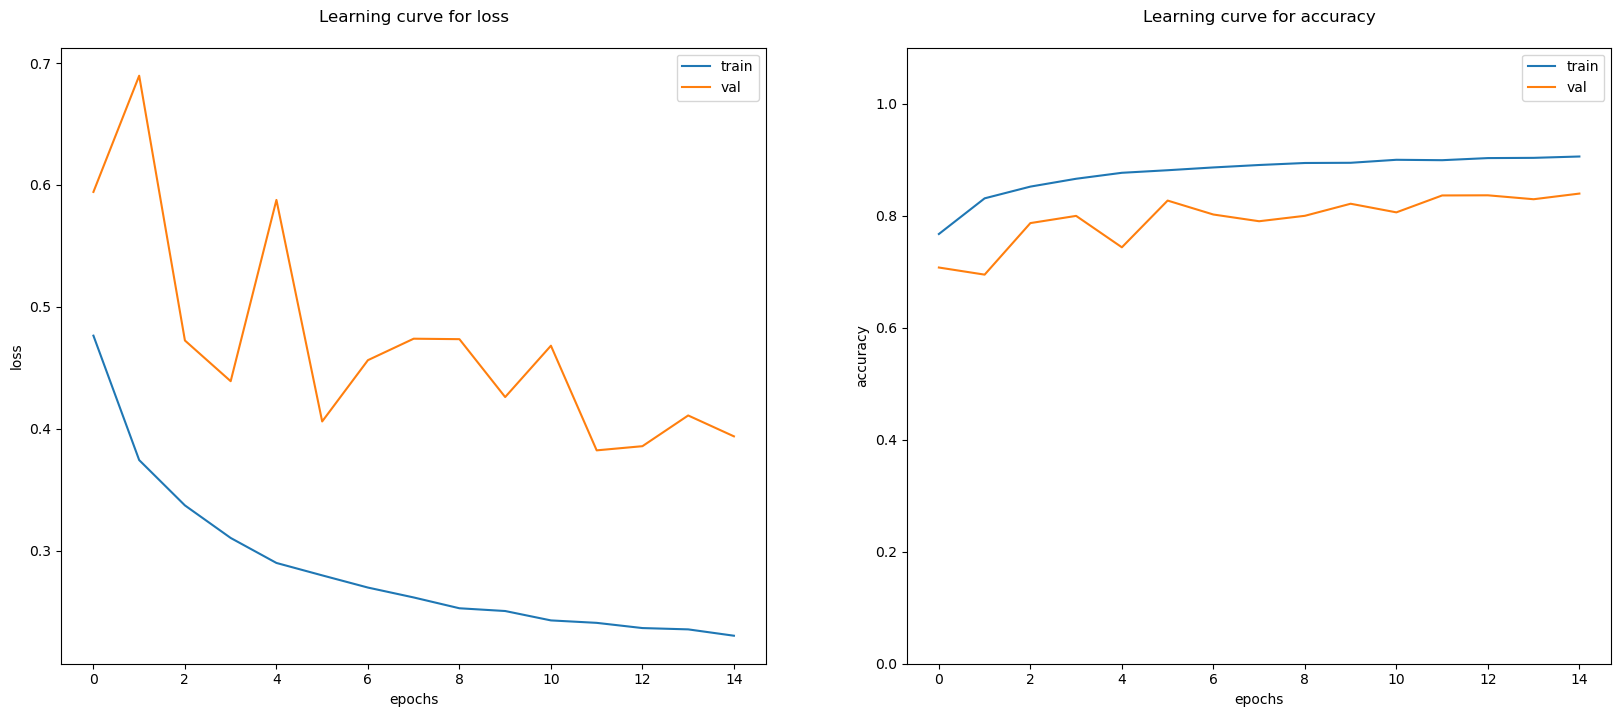

In [ ]:
plot_lc(model_history.history)

We see that there is moderate underfitting, meaning the model can probably learn more from the data.

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step


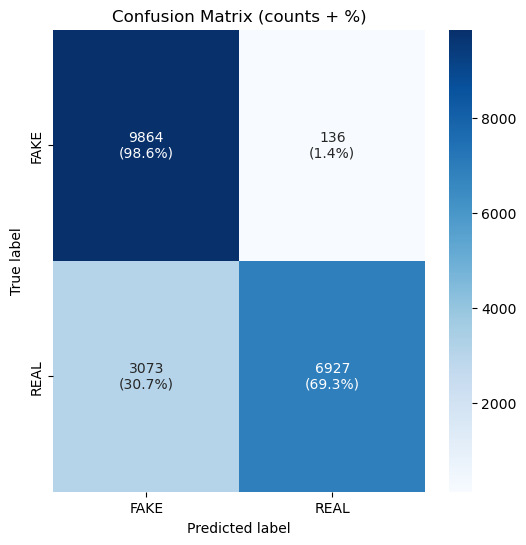

In [38]:
# 1. Get predictions
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # binary classification

# 2. Get true labels
_, y_true = dataset_to_numpy(test_ds)

# 3. Plot confusion matrix
plot_confusion_matrix_counts_percent(y_true, y_pred, class_names=['FAKE','REAL'])

### Build a second model (increased capacity)

In [ ]:
inputs = Input(IMG_SHAPE)

x = data_augmentation(inputs)   # apply data augmentation as a preprocessing layer at the start

x = Rescaling(1./255)(x)      # normalize after augmentation

x = Convolution2D(32, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(128, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)

x = Flatten()(x)

x = Dense(128, activation=ACTIVATION)(x)

outputs = Dense(1, activation='sigmoid')(x)

model_2 = Model(inputs, outputs)

# compile model
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train second model

In [42]:
model_2_history = model_2.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 76s 23ms/step - accuracy: 0.7588 - loss: 0.4911 - val_accuracy: 0.6366 - val_loss: 0.6999
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.8281 - loss: 0.3824 - val_accuracy: 0.7970 - val_loss: 0.4120
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8522 - loss: 0.3388 - val_accuracy: 0.7491 - val_loss: 0.5154
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8661 - loss: 0.3110 - val_accuracy: 0.7380 - val_loss: 0.5732
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8749 - loss: 0.2930 - val_accuracy: 0.6894 - val_loss: 0.7466
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8815 - loss: 0.2803 - val_accuracy: 0.7407 - val_loss: 0.5654
Epoch 7/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.8838 - loss: 0.2726 - val_accuracy: 0.7794 - val_loss: 0.5357
Epoch 8/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8887 -

In [43]:
loss, acc = model_2.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8143 - loss: 0.4639
Test Accuracy: 0.81


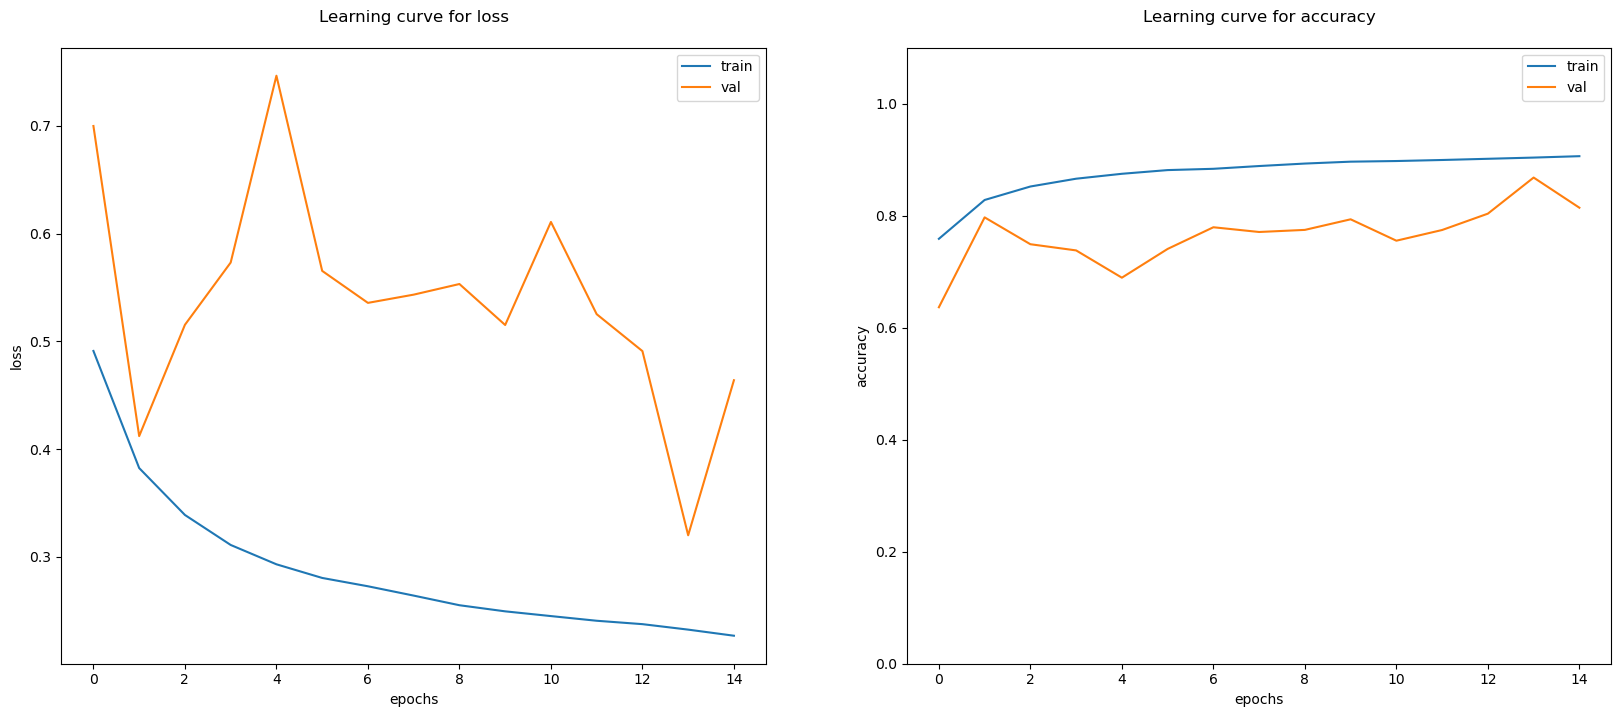

In [44]:
plot_lc(model_2_history.history)

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


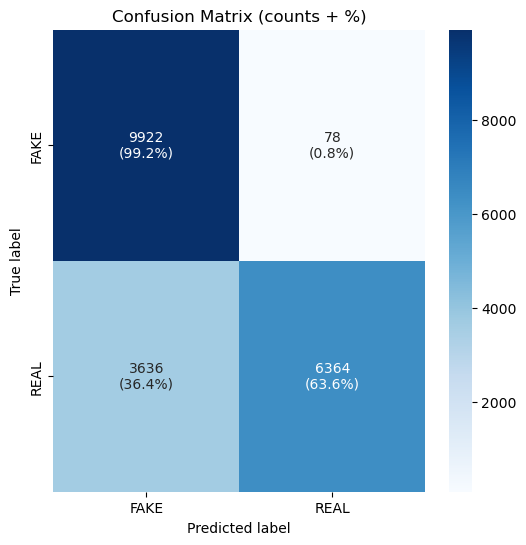

In [45]:
y_pred_prob_2 = model_2.predict(test_ds)
y_pred_2 = (y_pred_prob_2 > 0.5).astype(int).flatten()

_, y_true = dataset_to_numpy(test_ds)

plot_confusion_matrix_counts_percent(y_true, y_pred_2, class_names=['FAKE','REAL'])

🔹 Outcome
- Accuracy dropped from ~0.84 → ~0.81
- Loss increased from ~0.39 → ~0.46
- Class-wise performance imbalance became more noticeable

🔹 Key insights
- Underfitting isn’t solved just by “bigger model”.
- Sometimes a slightly simpler model + class-wise augmentation works better for imbalanced datasets.
- Loss is sensitive: even if accuracy is acceptable, higher loss shows the model is less confident in predictions.

### Build a third model, implementing class-wise augmentation

In [68]:
# --- Define separate augmentation pipelines ---

# --- Augmentation for FAKE images (light) ---
fake_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
], name="fake_augmentation")

# --- Augmentation for REAL images (stronger) ---
real_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomTranslation(0.1, 0.1),
    RandomBrightness(factor=0.1),
], name="real_augmentation")


# --- Function to apply batch-wise class-wise augmentation ---
def augment_classwise_batch(images, labels):
    # Create masks for each class
    fake_mask = tf.equal(labels, 0)
    real_mask = tf.equal(labels, 1)
    
    # Apply augmentations to each class
    images_fake = fake_augmentation(tf.boolean_mask(images, fake_mask))
    images_real = real_augmentation(tf.boolean_mask(images, real_mask))
    
    # Combine images back into original order
    images_out = tf.dynamic_stitch([tf.where(fake_mask)[:,0], tf.where(real_mask)[:,0]],
                                   [images_fake, images_real])
    
    # Restore original batch dimension
    images_out = tf.reshape(images_out, tf.shape(images))
    
    return images_out, labels

In [69]:
inputs = Input(IMG_SHAPE)
x = Rescaling(1./255)(inputs)  # normalization after augmentation

x = Convolution2D(32, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)

x = Flatten()(x)

x = Dense(64, activation=ACTIVATION)(x)
outputs = Dense(1, activation='sigmoid')(x)

class_aug_model = Model(inputs, outputs)

class_aug_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

class_aug_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train class-wise augmented model

In [73]:
model_3_history = class_aug_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.9883 - loss: 0.0320 - val_accuracy: 0.9262 - val_loss: 0.3466
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 57s 18ms/step - accuracy: 0.9893 - loss: 0.0301 - val_accuracy: 0.9280 - val_loss: 0.3347
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 55s 18ms/step - accuracy: 0.9905 - loss: 0.0261 - val_accuracy: 0.9284 - val_loss: 0.3559
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 56s 18ms/step - accuracy: 0.9892 - loss: 0.0298 - val_accuracy: 0.9219 - val_loss: 0.3947
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 56s 18ms/step - accuracy: 0.9905 - loss: 0.0261 - val_accuracy: 0.9284 - val_loss: 0.3966


In [76]:
loss, acc = class_aug_model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9284 - loss: 0.3966
Test Accuracy: 0.93


### Same as the third model, but adding Dropout

In [77]:
inputs = Input(IMG_SHAPE)
x = Rescaling(1./255)(inputs)

x = Convolution2D(32, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation=ACTIVATION)(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model_4_dropout = Model(inputs, outputs)

model_4_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_4_dropout.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model_4_history = model_4_dropout.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - accuracy: 0.8518 - loss: 0.3402 - val_accuracy: 0.9029 - val_loss: 0.2412
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.9002 - loss: 0.2467 - val_accuracy: 0.9154 - val_loss: 0.2081
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.9141 - loss: 0.2165 - val_accuracy: 0.9255 - val_loss: 0.1881
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - accuracy: 0.9209 - loss: 0.2000 - val_accuracy: 0.9168 - val_loss: 0.2059
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - accuracy: 0.9246 - loss: 0.1887 - val_accuracy: 0.9325 - val_loss: 0.1688


In [80]:
loss, acc = model_4_dropout.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9325 - loss: 0.1688
Test Accuracy: 0.93


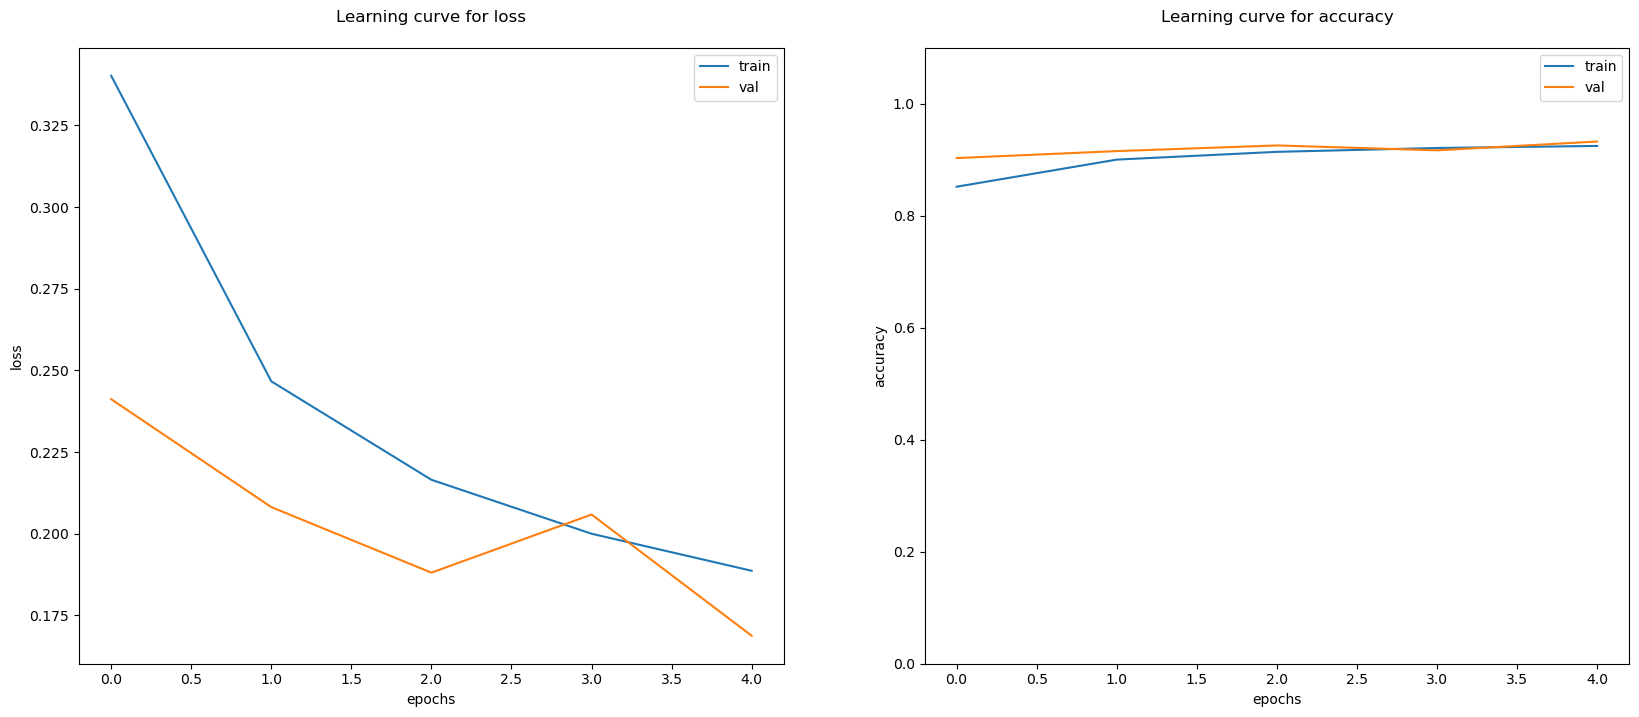

In [81]:
plot_lc(model_4_history.history)

In [82]:
import os

class_names = sorted(os.listdir('CIFAKE/train'))
class_to_label = {name: idx for idx, name in enumerate(class_names)}